In [1]:
import os
import shutil

source_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\uploads"
destination_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"

os.makedirs(destination_folder, exist_ok=True)

for filename in os.listdir(source_folder):
    source_file = os.path.join(source_folder, filename)
    dest_file = os.path.join(destination_folder, filename)

    if os.path.isfile(source_file):
        shutil.copy2(source_file, dest_file)

print("✅ Copy complete!")



✅ Copy complete!


In [29]:
!pip install opencv-python


In [2]:
import cv2
import numpy as np
import os

def apply_sma2_segmentation(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, segmented_image = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)
    return segmented_image

def segment_folder(input_folder, output_folder):
    if not os.path.exists(input_folder):
        print(f"Input folder {input_folder} does not exist!")
        return

    os.makedirs(output_folder, exist_ok=True)
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

    count = 1
    for filename in sorted(os.listdir(input_folder)):
        if filename.lower().endswith(image_extensions):
            image_path = os.path.join(input_folder, filename)
            image = cv2.imread(image_path)

            if image is None:
                print(f"Impossible de charger l'image {image_path}")
                continue

            segmented_image = apply_sma2_segmentation(image)

            new_name = f"image{count}.png"
            save_path = os.path.join(output_folder, new_name)

            # Save using OpenCV instead of plt
            cv2.imwrite(save_path, segmented_image)

            print(f"Processed {filename} -> {new_name}")

            count += 1

if __name__ == "__main__":
    input_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\uploads"
    output_folder = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"
    segment_folder(input_folder, output_folder)


Processed 2.jpg -> image1.png
Processed 3.jpg -> image2.png
Processed WhatsApp_Image_2025-06-01_at_13.11.07_2.jpeg -> image3.png
Processed WhatsApp_Image_2025-06-01_at_13.11.07_3.jpeg -> image4.png
Processed image20.png -> image5.png


In [10]:
import os
import cv2
import numpy as np
from glob import glob

# === Input folders ===
dossier_images = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination"          # Folder with COLOR images
dossier_masks = r"C:\Users\User\Downloads\Stage PFA CRNS\web\destination_mask"     # Folder with GRAYSCALE masks (.png)

# === Output folders ===
dossier_sortie_images = r"C:\Users\User\Downloads\Stage PFA CRNS\web\morceau_images"
dossier_sortie_masks = r"C:\Users\User\Downloads\Stage PFA CRNS\web\morceau_mask"

os.makedirs(dossier_sortie_images, exist_ok=True)
os.makedirs(dossier_sortie_masks, exist_ok=True)

# === Load and sort images and masks ===
images = sorted(glob(os.path.join(dossier_images, "*")))            # Accept all formats
masks = sorted(glob(os.path.join(dossier_masks, "*.png")))          # Only PNG masks

# === Validate ===
if len(images) != len(masks):
    print(f"⚠️ ERROR: {len(images)} images ≠ {len(masks)} masks")
    exit()

# === Patch settings ===
patch_size = 256
overlap = 0.5
stride = int(patch_size * (1 - overlap))  # 128 for 50% overlap

total_patches = 0

# === Loop through paired image/mask ===
for pair_index, (img_path, mask_path) in enumerate(zip(images, masks)):
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"⚠️ Could not read image or mask at index {pair_index}")
        continue

    h, w = img.shape[:2]
    index = 0

    for i in range(0, h, stride):
        for j in range(0, w, stride):
            # Extract patch from image and mask
            patch_img = img[i:i+patch_size, j:j+patch_size]
            patch_mask = mask[i:i+patch_size, j:j+patch_size]

            # Pad if smaller than patch size
            if patch_img.shape[0] != patch_size or patch_img.shape[1] != patch_size:
                pad_img = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                pad_img[:patch_img.shape[0], :patch_img.shape[1]] = patch_img
                patch_img = pad_img

            if patch_mask.shape[0] != patch_size or patch_mask.shape[1] != patch_size:
                pad_mask = np.zeros((patch_size, patch_size), dtype=np.uint8)
                pad_mask[:patch_mask.shape[0], :patch_mask.shape[1]] = patch_mask
                patch_mask = pad_mask

            # Save both patches with same name
            filename = f"pair_{pair_index:03d}_part{index:03d}.png"
            cv2.imwrite(os.path.join(dossier_sortie_images, filename), patch_img)
            cv2.imwrite(os.path.join(dossier_sortie_masks, filename), patch_mask)

            index += 1
            total_patches += 1

    print(f"✔ {index} patches created for pair {pair_index}")

print(f"🧩 Total patches created: {total_patches}")




✔ 192 patches created for pair 0
✔ 414 patches created for pair 1
✔ 80 patches created for pair 2
✔ 80 patches created for pair 3
✔ 80 patches created for pair 4
🧩 Total patches created: 846


In [2]:
import os
import numpy as np
import cv2
import torch  # PyTorch instead of TensorFlow
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2  # ✅ Keep this
import matplotlib.pyplot as plt  # ✅ No change



In [3]:
dossier_images =r"C:\Users\User\Downloads\Stage PFA CRNS\web\mourceau"

taille_image =256
batch_size = 4
epochs = 2


In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(height=taille_image, width=taille_image),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
    ToTensorV2()
])


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import os

class ImageMaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            raise FileNotFoundError(f"Could not load {img_path} or {mask_path}")

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]))
        mask = (mask > 127).astype(np.float32)  # Binarize mask to 0/1
        mask = np.expand_dims(mask, axis=-1)    # (H, W, 1)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]  # tensor [3,H,W]
            mask = augmented["mask"]  # tensor [H,W,1]

        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask)

        # Permute mask from [H,W,1] to [1,H,W]
        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1).contiguous()

        # DEBUG
        print(f"[Dataset] mask shape before return: {mask.shape}")

        return img, mask


# Instantiate Dataset and DataLoader
train_dataset = ImageMaskDataset(
    image_dir="C:/Users/User/Downloads/Stage PFA CRNS/web/morceau_images",
    mask_dir="C:/Users/User/Downloads/Stage PFA CRNS/web/morceau_mask",
    transform=train_transform  # Make sure this outputs tensors
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

In [6]:
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)
        self.enc5 = ConvBlock(512, 1024)
        self.pool5 = nn.MaxPool2d(2)

        # Bridge
        self.bridge = ConvBlock(1024, 2048)

        # Decoder
        self.up1 = nn.ConvTranspose2d(2048, 1024, 2, stride=2)
        self.dec1 = ConvBlock(2048, 1024)
        self.up2 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec2 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up4 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec4 = ConvBlock(256, 128)
        self.up5 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec5 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool1(s1))
        s3 = self.enc3(self.pool2(s2))
        s4 = self.enc4(self.pool3(s3))
        s5 = self.enc5(self.pool4(s4))

        # Bridge
        b = self.bridge(self.pool5(s5))

        # Decoder
        d1 = self.dec1(torch.cat([self.up1(b), s5], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d1), s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d2), s3], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d3), s2], dim=1))
        d5 = self.dec5(torch.cat([self.up5(d4), s1], dim=1))

        return torch.sigmoid(self.final(d5))


# Test run
model = UNet()
output = model(torch.randn(1, 3, 256, 256))
print(output.shape)  # Should be: torch.Size([1, 1, 256, 256])


torch.Size([1, 1, 256, 256])


In [7]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


PyTorch version: 2.0.1+cu118
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU


In [10]:
"""model training """
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

model = UNet()  # Instantiate the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("✅ Model is on:", next(model.parameters()).device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, verbose=True)

epochs = 10
best_loss = float("inf")
patience = 2
patience_counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for images, masks in tqdm(train_loader):
        images = images.to(device)
        masks = masks.to(device)
    
        
        


        print("📦 Input is on:", images.device)  # ✅ Now inputs exist, safe to check their device

        optimizer.zero_grad()
        outputs = model(images)  # No sigmoid here
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    scheduler.step(epoch_loss)

    print(f"📉 Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

    # ✅ Early stopping
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        patience_counter = 0
        torch.save(model.state_dict(), "5_without_self.pth")
        print("✅ Model saved.")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹️ Early stopping triggered.")
            break


✅ Model is on: cuda:0


  0%|                                                                                          | 0/212 [00:00<?, ?it/s]

[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
📦 Input is on: cuda:0


  0%|▍                                                                                 | 1/212 [00:01<05:23,  1.53s/it]

[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
📦 Input is on: cuda:0


...

[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
📦 Input is on: cuda:0


100%|███████████████████████████████████████████████████████████████████████████████▌| 211/212 [01:30<00:00,  2.35it/s]

[Dataset] mask shape before return: torch.Size([1, 256, 256])
[Dataset] mask shape before return: torch.Size([1, 256, 256])
📦 Input is on: cuda:0


100%|████████████████████████████████████████████████████████████████████████████████| 212/212 [01:30<00:00,  2.33it/s]

📉 Epoch 5/10, Loss: 0.5270
⏹️ Early stopping triggered.


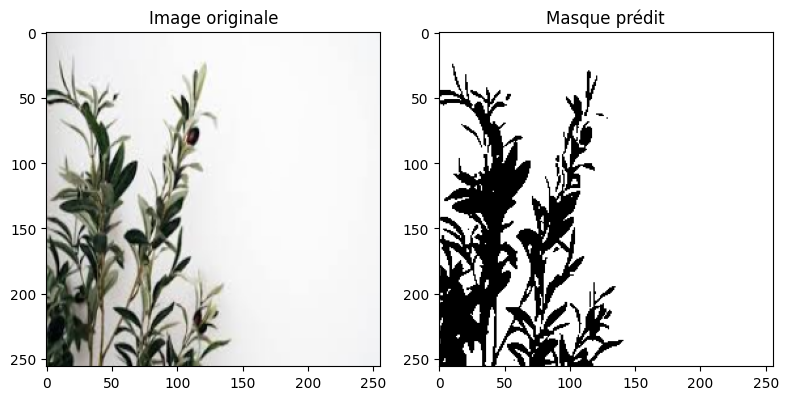

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/images.jpg"
taille_image = 256
model_path = "5_without_self.pth"  # Path where you saved the model with torch.save

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet()  # Replace with your actual UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode

# === Load and preprocess the image ===
image = cv2.imread(image_path)
image = cv2.resize(image, (taille_image, taille_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = image_rgb / 255.0  # Normalize to [0, 1]
image_tensor = torch.from_numpy(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)
# shape: (1, 3, 256, 256)

# === Predict ===
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = (output.squeeze().cpu().numpy() > 0.4).astype(np.uint8)
# shape: (256, 256)

# === Visualization ===
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.title("Masque prédit")
plt.imshow(pred_mask, cmap='gray')

plt.tight_layout()
plt.show()



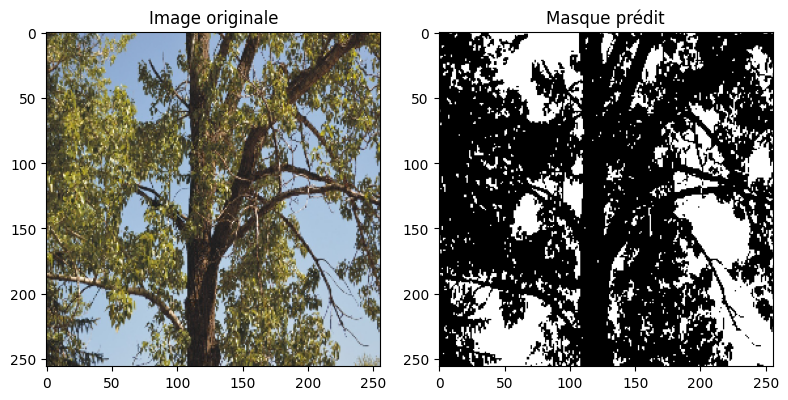

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/tree.jpg"
taille_image = 256
model_path = "5_without_self.pth"  # Path where you saved the model with torch.save

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet()  # Replace with your actual UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode

# === Load and preprocess the image ===
image = cv2.imread(image_path)
image = cv2.resize(image, (taille_image, taille_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = image_rgb / 255.0  # Normalize to [0, 1]
image_tensor = torch.from_numpy(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)
# shape: (1, 3, 256, 256)

# === Predict ===
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = (output.squeeze().cpu().numpy() > 0.4).astype(np.uint8)
# shape: (256, 256)

# === Visualization ===
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.title("Masque prédit")
plt.imshow(pred_mask, cmap='gray')

plt.tight_layout()
plt.show()



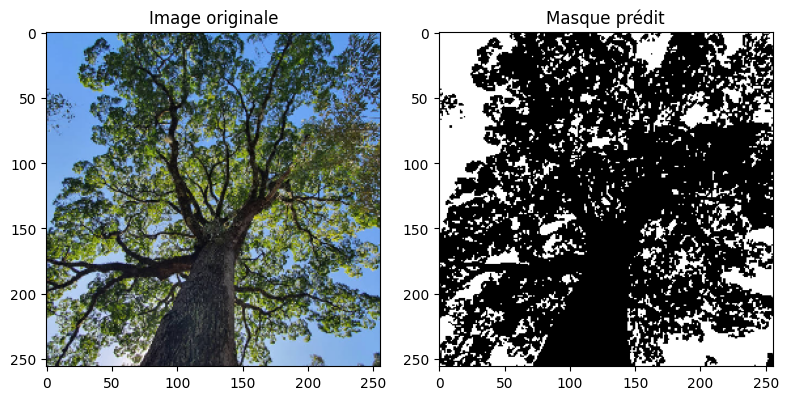

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/ima.jpg"
taille_image = 256
model_path = "5_without_self.pth"  # Path where you saved the model with torch.save

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet()  # Replace with your actual UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  # Set model to evaluation mode

# === Load and preprocess the image ===
image = cv2.imread(image_path)
image = cv2.resize(image, (taille_image, taille_image))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_norm = image_rgb / 255.0  # Normalize to [0, 1]
image_tensor = torch.from_numpy(image_norm).permute(2, 0, 1).unsqueeze(0).float().to(device)
# shape: (1, 3, 256, 256)

# === Predict ===
with torch.no_grad():
    output = model(image_tensor)
    pred_mask = (output.squeeze().cpu().numpy() > 0.4).astype(np.uint8)
# shape: (256, 256)

# === Visualization ===
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.title("Image originale")
plt.imshow(image_rgb)

plt.subplot(1, 2, 2)
plt.title("Masque prédit")
plt.imshow(pred_mask, cmap='gray')

plt.tight_layout()
plt.show()



In [15]:
import os
import random
import numpy as np
import torch
import cv2
from sklearn.metrics import accuracy_score, recall_score
from model1 import UNet  # Or whatever your model class is
from torchvision import transforms

# 🔧 Parameters
taille_image = 256
sample_size = 5
dossier_images = "C:/Users/User/Downloads/Stage PFA CRNS/web/uploads"
model_path = "5_without_self.pth"

# 🧠 Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet()
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# 📂 List image files
image_paths = [os.path.join(dossier_images, f)
               for f in os.listdir(dossier_images)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_paths = random.sample(image_paths, min(sample_size, len(image_paths)))

y_true_all = []
y_pred_all = []

# 🔁 Inference loop
for img_path in image_paths:
    img = cv2.imread(img_path)
    mask = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        continue

    img = cv2.resize(img, (taille_image, taille_image), interpolation=cv2.INTER_CUBIC)
    mask = cv2.resize(mask, (taille_image, taille_image), interpolation=cv2.INTER_NEAREST)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mask = (mask > 127).astype(np.uint8)

    # [H, W, C] → [1, C, H, W]
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred = model(img_tensor)
        pred = pred.squeeze().cpu().numpy()  # shape: [H, W]

    pred_bin = (pred > 0.8).astype(np.uint8)

    y_true_all.extend(mask.flatten())
    y_pred_all.extend(pred_bin.flatten())

# 📊 Metrics
accuracy = accuracy_score(y_true_all, y_pred_all)
recall = recall_score(y_true_all, y_pred_all)

print(f"✅ Accuracy (on {len(image_paths)} images): {accuracy:.4f}")
print(f"✅ Recall   (on {len(image_paths)} images): {recall:.4f}")


✅ Accuracy (on 5 images): 0.8504
✅ Recall   (on 5 images): 0.8100


In [16]:
from sklearn.metrics import precision_score, f1_score

precision = precision_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all)

print(f"✅ Precision : {precision:.4f}")
print(f"✅ F1-score  : {f1:.4f}")

✅ Precision : 0.8878
✅ F1-score  : 0.8471


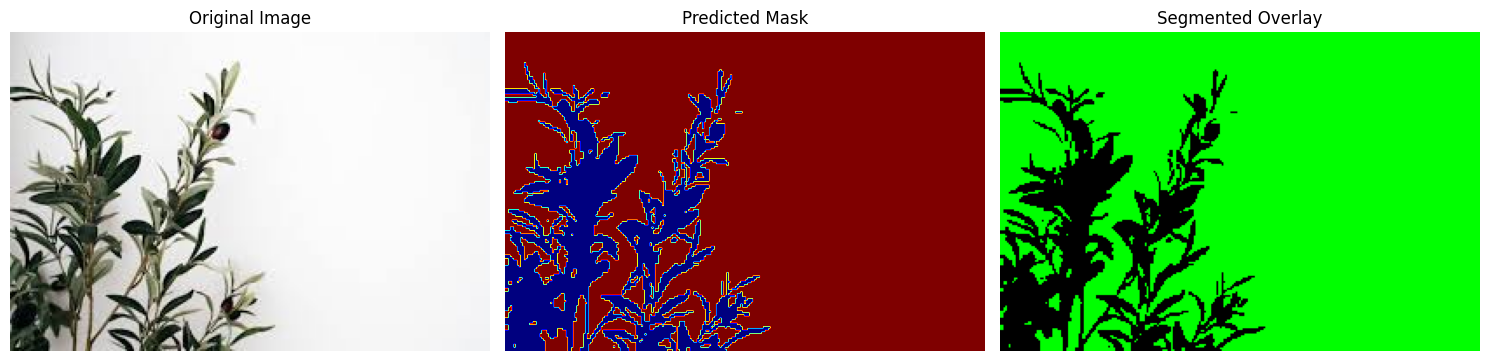

✅ Image segmentée enregistrée à : C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg


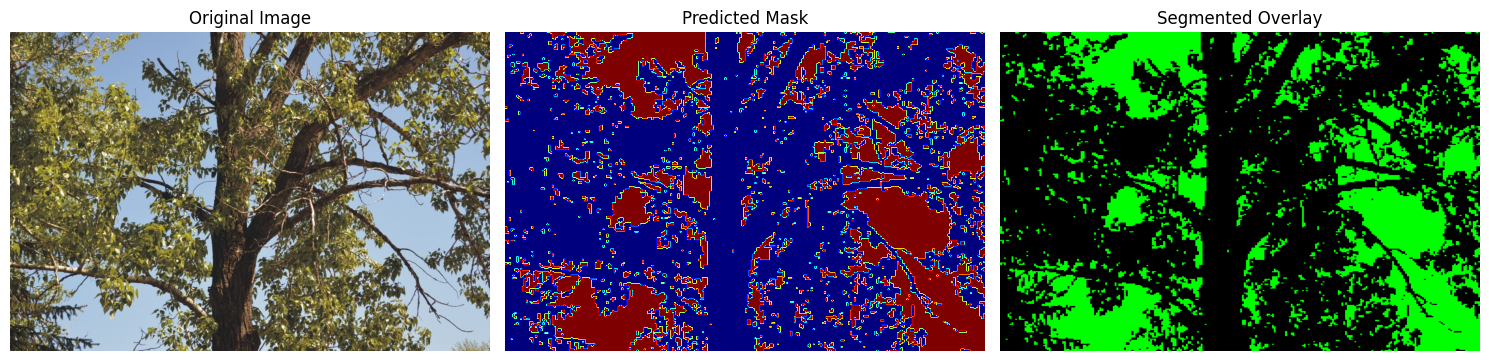

✅ Image segmentée enregistrée à : C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg


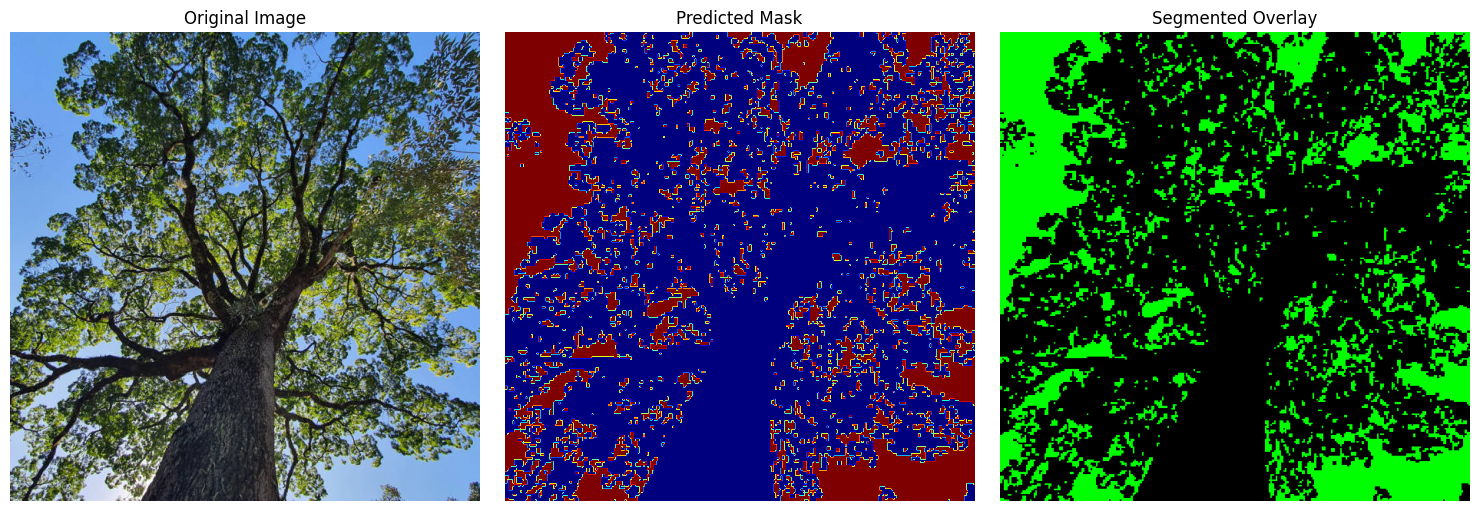

✅ Image segmentée enregistrée à : C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg


In [18]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/images.jpg"
taille_modele = 256  # input size for the model
model_path = "5_without_self.pth"

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet()  # or your UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# === Load original image ===
image_orig = cv2.imread(image_path)
image_rgb_orig = cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB)

# === Resize for the model input ===
image_small = cv2.resize(image_rgb_orig, (taille_modele, taille_modele))
image_input = image_small.astype(np.float32) / 255.0
image_input = torch.from_numpy(image_input).permute(2, 0, 1).unsqueeze(0).to(device)

# === Predict ===
with torch.no_grad():
    output = model(image_input)
    output = output.squeeze().cpu().numpy()

if output.ndim == 3 and output.shape[0] > 1:  # Multi-class (C, H, W)
    pred_mask = np.argmax(output, axis=0)
else:  # Binary
    pred_mask = (output > 0.4).astype(np.uint8)

# === Resize mask back to original size ===
mask_resized = cv2.resize(pred_mask.astype(np.uint8), (image_rgb_orig.shape[1], image_rgb_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Define colors per class ===
colors = {
    0: [0, 0, 0],       # Background
    1: [0, 255, 0],     # Class 1
    2: [255, 0, 0],     # Class 2 (optional)
}

# === Create color image ===
segmented_image = np.zeros_like(image_rgb_orig)
for class_id, color in colors.items():
    segmented_image[mask_resized == class_id] = color

# === Plot ===
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb_orig)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Predicted Mask")
plt.imshow(mask_resized, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Segmented Overlay")
plt.imshow(segmented_image)
plt.axis('off')

plt.tight_layout()
plt.show()

# === Save the segmented image ===
save_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg"
cv2.imwrite(save_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
print(f"✅ Image segmentée enregistrée à : {save_path}")


import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/tree.jpg"
taille_modele = 256  # input size for the model
model_path = "5_without_self.pth"

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet()  # or your UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# === Load original image ===
image_orig = cv2.imread(image_path)
image_rgb_orig = cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB)

# === Resize for the model input ===
image_small = cv2.resize(image_rgb_orig, (taille_modele, taille_modele))
image_input = image_small.astype(np.float32) / 255.0
image_input = torch.from_numpy(image_input).permute(2, 0, 1).unsqueeze(0).to(device)

# === Predict ===
with torch.no_grad():
    output = model(image_input)
    output = output.squeeze().cpu().numpy()

if output.ndim == 3 and output.shape[0] > 1:  # Multi-class (C, H, W)
    pred_mask = np.argmax(output, axis=0)
else:  # Binary
    pred_mask = (output > 0.4).astype(np.uint8)

# === Resize mask back to original size ===
mask_resized = cv2.resize(pred_mask.astype(np.uint8), (image_rgb_orig.shape[1], image_rgb_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Define colors per class ===
colors = {
    0: [0, 0, 0],       # Background
    1: [0, 255, 0],     # Class 1
    2: [255, 0, 0],     # Class 2 (optional)
}

# === Create color image ===
segmented_image = np.zeros_like(image_rgb_orig)
for class_id, color in colors.items():
    segmented_image[mask_resized == class_id] = color

# === Plot ===
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb_orig)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Predicted Mask")
plt.imshow(mask_resized, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Segmented Overlay")
plt.imshow(segmented_image)
plt.axis('off')

plt.tight_layout()
plt.show()

# === Save the segmented image ===
save_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg"
cv2.imwrite(save_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
print(f"✅ Image segmentée enregistrée à : {save_path}")

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from model1 import UNet  # Replace with your model class

# === Parameters ===
image_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/ima.jpg"
taille_modele = 256  # input size for the model
model_path = "5_without_self.pth"

# === Load the model ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet()  # or your UNet class
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# === Load original image ===
image_orig = cv2.imread(image_path)
image_rgb_orig = cv2.cvtColor(image_orig, cv2.COLOR_BGR2RGB)

# === Resize for the model input ===
image_small = cv2.resize(image_rgb_orig, (taille_modele, taille_modele))
image_input = image_small.astype(np.float32) / 255.0
image_input = torch.from_numpy(image_input).permute(2, 0, 1).unsqueeze(0).to(device)

# === Predict ===
with torch.no_grad():
    output = model(image_input)
    output = output.squeeze().cpu().numpy()

if output.ndim == 3 and output.shape[0] > 1:  # Multi-class (C, H, W)
    pred_mask = np.argmax(output, axis=0)
else:  # Binary
    pred_mask = (output > 0.4).astype(np.uint8)

# === Resize mask back to original size ===
mask_resized = cv2.resize(pred_mask.astype(np.uint8), (image_rgb_orig.shape[1], image_rgb_orig.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Define colors per class ===
colors = {
    0: [0, 0, 0],       # Background
    1: [0, 255, 0],     # Class 1
    2: [255, 0, 0],     # Class 2 (optional)
}

# === Create color image ===
segmented_image = np.zeros_like(image_rgb_orig)
for class_id, color in colors.items():
    segmented_image[mask_resized == class_id] = color

# === Plot ===
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(image_rgb_orig)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Predicted Mask")
plt.imshow(mask_resized, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Segmented Overlay")
plt.imshow(segmented_image)
plt.axis('off')

plt.tight_layout()
plt.show()

# === Save the segmented image ===
save_path = "C:/Users/User/Downloads/Stage PFA CRNS/collab/image_segmented.jpg"
cv2.imwrite(save_path, cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR))
print(f"✅ Image segmentée enregistrée à : {save_path}")
